In [2]:
# Library
from sklearn.linear_model import LinearRegression

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thay đổi theme background của đồ thị
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

### **1. Dataset**

**Mô tả dữ liệu**
Hai bộ dữ liệu này có liên quan đến các biến thể màu đỏ và trắng của rượu vang "Vinho Verde" của Bồ Đào Nha. Để biết thêm chi tiết, hãy tham khảo: http://www.vinhoverde.pt/en/ hoặc tài liệu tham khảo [Cortez et al., 2009]. Do các vấn đề về quyền riêng tư và hậu cần, chỉ có các biến hóa lý (đầu vào) và cảm quan (đầu ra) (ví dụ: không có dữ liệu về loại nho, nhãn hiệu rượu, giá bán rượu, v.v.).

- **Đặc điểm dữ liệu**: đa biến (Multivariate)
- **Lĩnh vực chủ đề**: Business
- **Associated Tasks**: Classification, Regression
- **Kiểu dữ liệu**: Real
- **Số lượng instances**: 4898 (white) - 1599 (red)
- **Số lượng features**: 11

**Các features**:

| Variable Name         | Role	    | Type	        | Description            | Units  |	Missing Values |
| :--                   | :--       | :--           | :--                    | :--    | :--            |
| fixed_acidity         | Feature   | Continuous    | 		                 |        | no             |
| volatile_acidity      | Feature   | Continuous    | 		                 |        | no             |
| citric_acid           | Feature   | Continuous    | 		                 |        | no             |
| residual_sugar        | Feature   | Continuous    | 		                 |        | no             |
| chlorides             | Feature   | Continuous    | 		                 |        | no             |
| free_sulfur_dioxide   | Feature   | Continuous    | 		                 |        | no             |
| total_sulfur_dioxide  | Feature   | Continuous    | 		                 |        | no             |
| density               | Feature   | Continuous    | 		                 |        | no             |
| pH                    | Feature   | Continuous    | 		                 |        | no             |
| sulphates             | Feature   | Continuous    | 		                 |        | no             |
| alcohol               | Feature   | Continuous    | 		                 |        | no             |
| quality               | Target    | Integer	    | score between 0 and 10 | 	      | no             |

In [4]:
# Sử dụng cả bộ dữ liệu red và white cho bài toàn dự đoán chất lượng rượu
def initDataset():
    redWineData = pd.read_csv('./wine+quality/winequality-red.csv', sep=';')
    whiteWineData = pd.read_csv('./wine+quality/winequality-white.csv', sep=';')
    return pd.concat([redWineData, whiteWineData])

# Tạo dữ liệu
data = initDataset()
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# Kích thước dữ liệu
data.shape

(6497, 12)

In [6]:
# Trung bình, phương sai, độ lệch chuẩn, ...
data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [7]:
# Tổng quan dữ liệu
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 659.9 KB


### **2. Trực quan hoá dữ liệu**


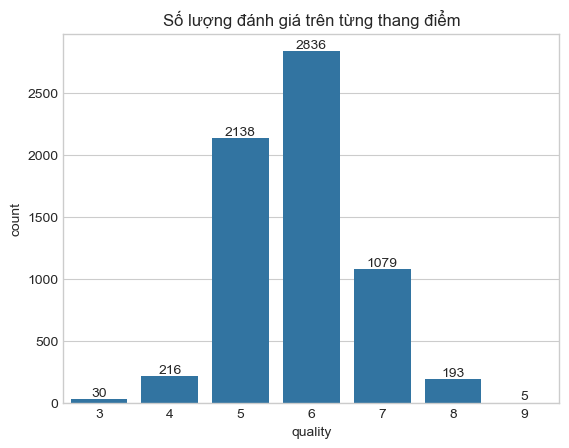

In [47]:
# Số lượng đánh giá trên từng thang điểm
numberOfValuation = data.quality.value_counts().sort_index(ascending=True)
numberOfValuation
ax = sns.countplot(x='quality', data=data)
plt.title('Số lượng đánh giá trên từng thang điểm');
ax.bar_label(container=ax.containers[0], labels=numberOfValuation);

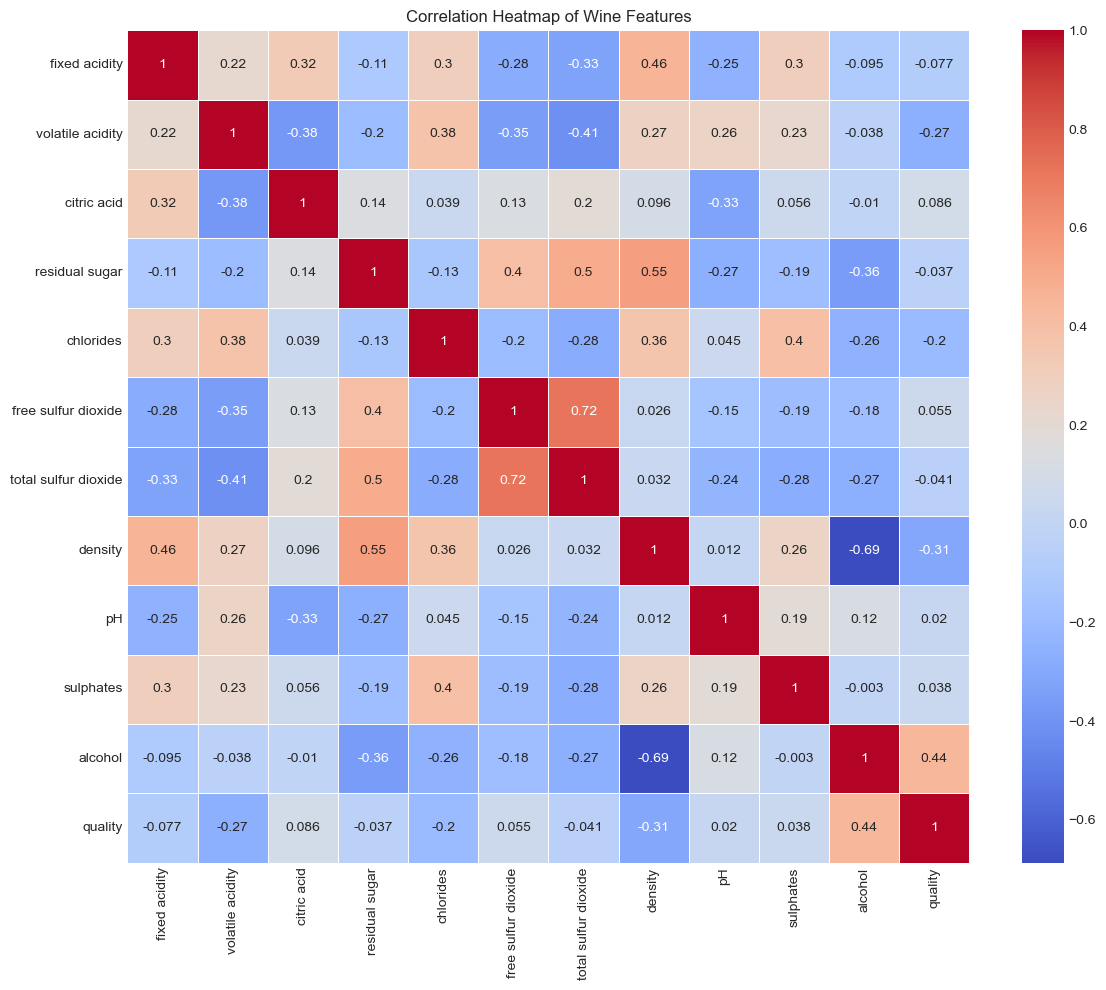

In [9]:
# Mối tương quan giữa các feature
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Wine Features')
plt.tight_layout()
plt.show()

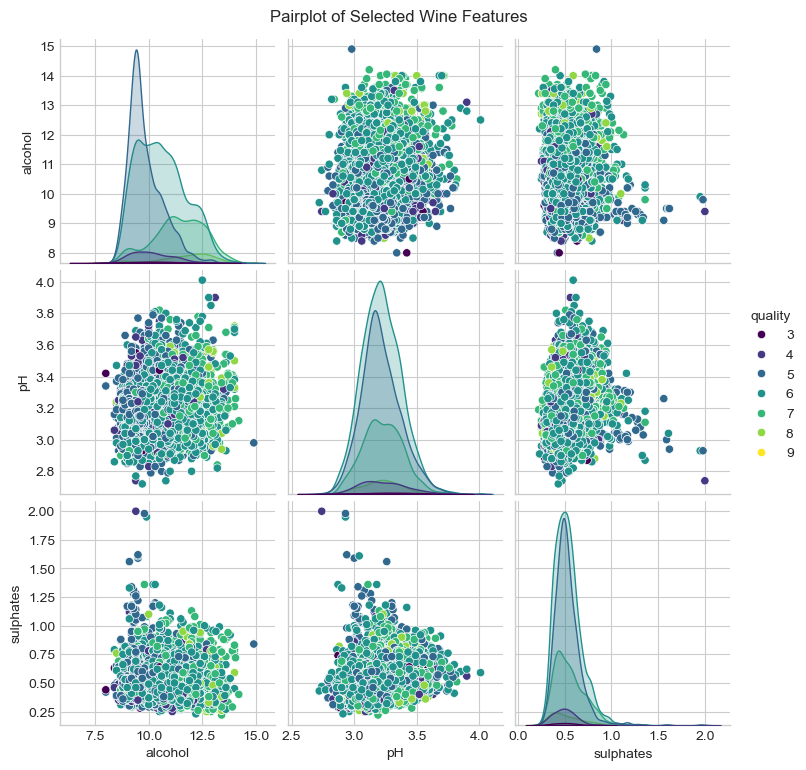

In [10]:
# 2. Pairplot for selected features
selected_features = ['alcohol', 'pH', 'sulphates', 'quality']
sns.pairplot(data[selected_features], hue='quality', palette='viridis')
plt.suptitle('Pairplot of Selected Wine Features', y=1.02)
plt.show()

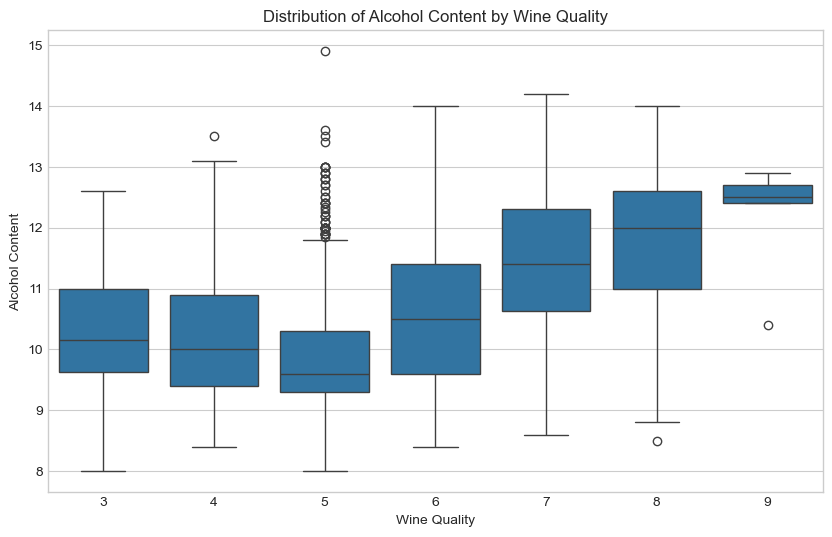

In [11]:
# 3. Box plot of quality vs. alcohol
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=data)
plt.title('Distribution of Alcohol Content by Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Alcohol Content')
plt.show()

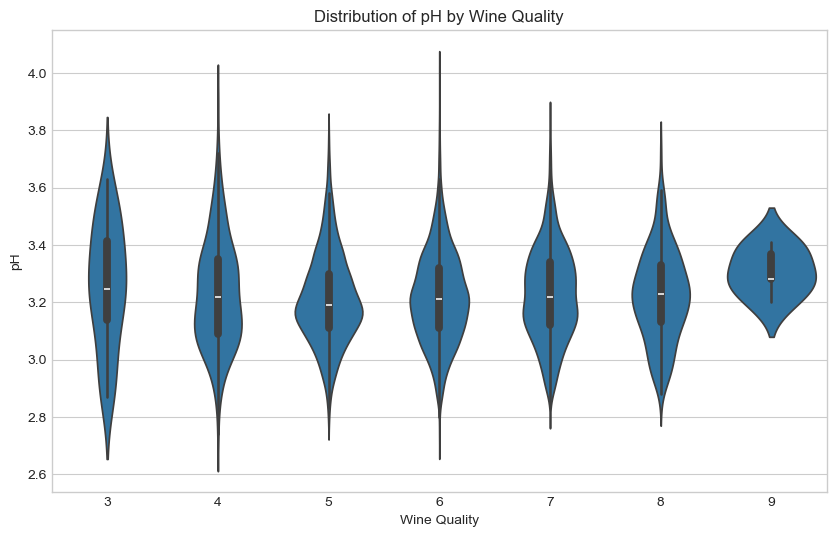

In [12]:
# 4. Violin plot of pH vs. quality
plt.figure(figsize=(10, 6))
sns.violinplot(x='quality', y='pH', data=data)
plt.title('Distribution of pH by Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('pH')
plt.show()

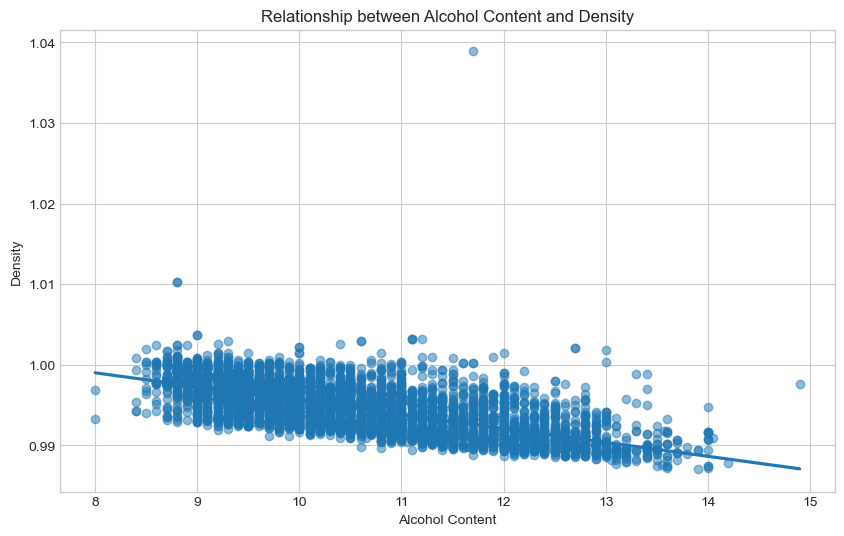

In [13]:
# 5. Scatter plot with regression line (alcohol vs. density)
plt.figure(figsize=(10, 6))
sns.regplot(x='alcohol', y='density', data=data, scatter_kws={'alpha':0.5})
plt.title('Relationship between Alcohol Content and Density')
plt.xlabel('Alcohol Content')
plt.ylabel('Density')
plt.show()

### **3. Tiền xử lý dữ liệu**